<a href="https://colab.research.google.com/github/seungmei/QNS/blob/main/PTCDA%2BFe_huckel_theory_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PTCDA + Fe Huckel Model: HOMO Peak Shift Mechanism

- Mechanism-only toy model.
- Goal: explain why the PTCDA-derived HOMO dI/dV peak shifts to lower sample bias when more Fe atoms bind near the end carbonyl groups.

Kept physics:

1. Fe-O hybridization: an effective Fe d-like site couples to carbonyl O through beta_Fe_O.
2. Local electrostatic stabilization: Fe lowers nearby PTCDA on-site energies through a distance-decaying potential.



In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Origin-style publication plot defaults: closed 4-spine frame, inward ticks,
# minor ticks, thicker axis lines. Set once so every later plot inherits it.
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11,
    'mathtext.fontset': 'dejavusans',
    'axes.linewidth': 1.4,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlepad': 8,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.grid': False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.frameon': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    'legend.fontsize': 9,
    'lines.linewidth': 1.8,
    'lines.markersize': 6,
    'lines.markeredgewidth': 1.2,
})


# Apply Origin-style axes (inward ticks, minor ticks, thicker spines) in one call.
def origin_style(ax, minor=True):
    ax.tick_params(which='both', direction='in', top=True, right=True)
    if minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)
    return ax


np.set_printoptions(precision=4, suppress=True)


## 1. Huckel and LDOS functions

build AO Hamiltonian -> diagonalize -> broaden each MO with a Lorentzian.

$$H_{ii}=\alpha_i, \qquad H_{ij}=\beta_{ij}\quad \text{if sites i and j are bonded.}$$

$$H C = C E, \qquad dI/dV(V) \propto \sum_n w_n L(V-V_n;\gamma).$$

In [44]:
def make_hamiltonian(n_sites, onsite, bonds):
    H = np.zeros((n_sites, n_sites), dtype=float)
    H[np.arange(n_sites), np.arange(n_sites)] = onsite
    for i, j, beta in bonds:
        H[i, j] = H[j, i] = beta
    return H


def solve_huckel(H):
    if not np.allclose(H, H.T, atol=1e-12):
        raise ValueError('Hamiltonian must be symmetric')
    return np.linalg.eigh(H)

#discrete MO energy list to continuous dI/dV-like spectrum
# dI/dV(V) ∝ Σ_n w_n L(V - V_n; γ)
#center: orbital energy, bias
#gamma: peak half-width, broadening strength
#x: energy/bias axis
#normalization needed.  <- ideal: like-delta function.
def lorentzian(x, center, gamma):
    return gamma / (np.pi * ((x - center)**2 + gamma**2))

# +1e-15 for avoiding value NaN
def normalize_peak(y):
    return np.asarray(y) / (np.nanmax(np.abs(y)) + 1e-15)

# weight=None: all orbital same weight
# instead of for loop and summing up all peaks -> broadened_spectrum
def broadened_spectrum(centers, V_axis, gamma, weights=None):
    centers = np.asarray(centers)
    if weights is None:
        weights = np.ones_like(centers)
    peaks = lorentzian(V_axis[None, :], centers[:, None], gamma)
    return np.sum(np.asarray(weights)[:, None] * peaks, axis=0)

## 2. Benzene sanity check

Engine validation against the analytic Hückel result $\{-2,-1,-1,+1,+1,+2\}\,|\beta|$
including the $C_6$-symmetry doubly-degenerate $\pm 1$ levels.

- expected energy for benzene
$$E_k = \alpha + 2\beta \cos\left(\frac{2\pi k}{N}\right) \quad (k = 0, 1, \dots, N-1)$$
  - alpha: Coulomb Integral/On-site energy(Let's set this to 0)
  - beta: Resonance Integral/Hopping energy

Calculated benzene energies: [-2. -1. -1.  1.  1.  2.]
Expected benzene energies:   [-2. -1. -1.  1.  1.  2.]
Maximum error: 4.440892098500626e-16


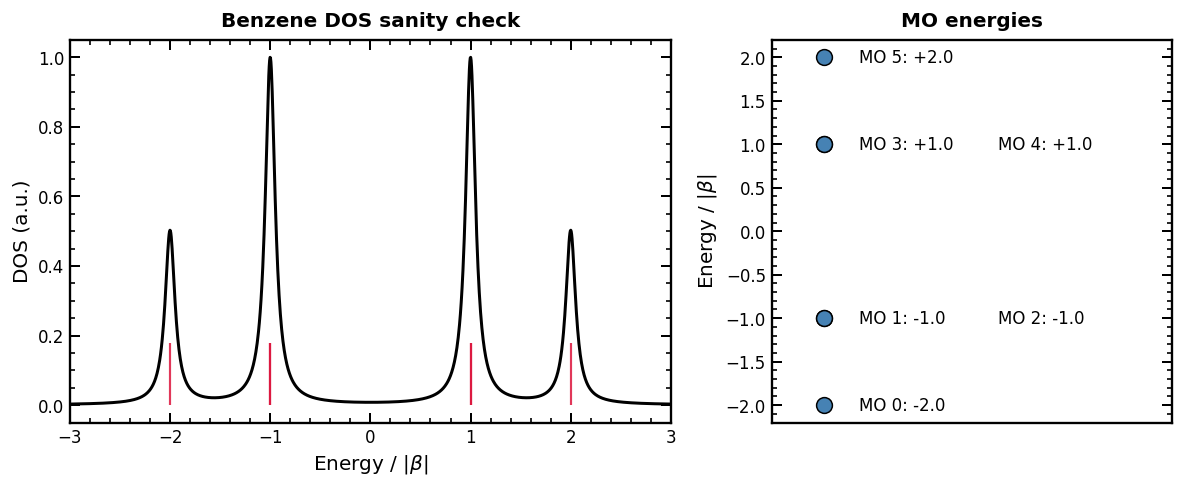

In [45]:
# Build benzene pi Hamiltonian with cyclic boundary conditions.
def build_benzene(alpha=0.0, beta=-1.0):
    onsite = [alpha] * 6
    # connecting bonds
    bonds = [(i, (i + 1) % 6, beta) for i in range(6)]
    H = make_hamiltonian(6, onsite, bonds)
    E, C = solve_huckel(H)
    return H, E, C


H_benz, E_benz, C_benz = build_benzene()
expected = np.array([-2, -1, -1, 1, 1, 2], dtype=float)
# error
error = np.max(np.abs(E_benz - expected))
print('Calculated benzene energies:', np.round(E_benz, 6))
print('Expected benzene energies:  ', expected)
print('Maximum error:', error)
assert error < 1e-10

V_benz = np.linspace(-3, 3, 1400)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2),
                         gridspec_kw={'width_ratios': [1.5, 1]})

# (left figure) total DOS + delta vlines
axes[0].plot(V_benz, normalize_peak(broadened_spectrum(E_benz, V_benz, gamma=0.06)),
             color='black', lw=1.8)
axes[0].vlines(E_benz, 0, 0.18, color='crimson', alpha=0.85, lw=1.3)
axes[0].set_xlabel(r'Energy / $|\beta|$')
axes[0].set_ylabel('DOS (a.u.)')
axes[0].set_title('Benzene DOS sanity check')
axes[0].set_xlim(-3, 3)
origin_style(axes[0])

# (right figure) MO ladder
axes[1].scatter(np.zeros_like(E_benz), E_benz, s=90, color='steelblue',
                edgecolor='black', linewidth=0.9, zorder=3)

# overlapping energy level
energy_counts = {}

for idx, e in enumerate(E_benz):
    e_rounded = round(e, 3)
    count = energy_counts.get(e_rounded, 0)

    # 같은 에너지일 경우 x좌표를 0.4만큼 오른쪽으로 밀어서 출력
    x_pos = 0.10 + (count * 0.4)

    axes[1].text(x_pos, e, f'MO {idx}: {e:+.1f}', va='center', fontsize=10)
    # 해당 에너지 레벨의 카운트 증가
    energy_counts[e_rounded] = count + 1

axes[1].set_xlim(-0.15, 1.0)
axes[1].set_xticks([])
axes[1].set_ylabel(r'Energy / $|\beta|$')
axes[1].set_title('MO energies')
origin_style(axes[1], minor=False)
axes[1].tick_params(axis='x', which='both', bottom=False, top=False)
plt.tight_layout()
plt.show()


## 3. PTCDA + Fe Huckel matrix

PTCDA is reduced to 30 pi sites: 20 perylene C, 4 carbonyl C, 4 carbonyl O, and 2 bridge O. With the assumed 32 pi electrons, the free-PTCDA HOMO index is 15 and LUMO index is 16.

Each Fe atom is one effective d-like site. Fe does not add pi electrons in this model; it perturbs PTCDA-derived orbitals through Fe-O hopping and distance-decaying on-site stabilization.

In [46]:
# =====================================================================
# Effective parameters (NOT ab initio).
#   alpha (on-site)     : more negative -> deeper atomic level (higher electronegativity).
#   beta  (hopping)     : negative -> bonding overlap. Larger |beta| -> stronger coupling.
#   electrostatic_*     : absorb Fe-induced local potential well via exp decay.
#   gamma               : Lorentzian half-width (lifetime + instrument + thermal).
# =====================================================================
PARAMS = {
    # schematic geometry (Å)
    'a_cc':   1.40,                # C-C bond length
    'a_fe_o': 2.00,                # Fe-O coordination distance

    # onsite energies alpha_i (eV)
    'alpha_c':           0.00,     # carbon p_z reference
    'alpha_o_carbonyl': -2.70,     # carbonyl O — electronegative, deep lone pair
    'alpha_o_bridge':   -1.60,     # anhydride bridge O — sp2 lone pair raised
    'alpha_fe':         +0.80,     # Fe d-like effective level (above carbon)

    # hopping beta_ij (eV)
    'beta_cc':         -2.70,      # standard perylene C=C pi
    'beta_co_double':  -2.40,      # C=O double bond
    'beta_co_single':  -1.90,      # C-O-C single bond to bridge
    'beta_fe_o':       -1.20,      # Fe-O coordination hopping

    # Fe-induced local electrostatics
    'electrostatic_shift': -0.08,  # max on-site stabilization at Fe (eV)
    'electrostatic_decay':  2.20,  # exponential decay length (Å)

    # dI/dV broadening
    'gamma': 0.08,
}

N_PTCDA_SITES = 30
N_PTCDA_ELECTRONS = 32
HOMO_INDEX = N_PTCDA_ELECTRONS // 2 - 1   # 15
LUMO_INDEX = HOMO_INDEX + 1               # 16
CARBONYL_O = [24, 25, 26, 27]             # site indices of the 4 carbonyl O (Fe binds here)


# Safe shallow copy for parameter overrides.
def params_with(update=None):
    p = dict(PARAMS)
    if update:
        p.update(update)
    return p


# Build PTCDA's 30-site schematic geometry plus its bond list.
# Layout: top naphthalene + bottom naphthalene + 4 carbonyl C + 4 carbonyl O + 2 bridge O.
# Bond list is (i, j, beta_ij) tuples passed straight to make_hamiltonian.
def build_ptcda_geometry(params=None):
    p = params_with(params)
    a = p['a_cc']
    sx = a * np.sqrt(3) / 2

    naph = np.array([
        [0.0, a/2], [0.0, -a/2],
        [sx, a], [2*sx, a/2], [2*sx, -a/2], [sx, -a],
        [-sx, a], [-2*sx, a/2], [-2*sx, -a/2], [-sx, -a],
    ])
    naph_top = naph + np.array([0.0,  1.5*a])
    naph_bottom = naph + np.array([0.0, -1.5*a])

    c_top_r = np.array([ sx,  3.5*a])
    c_top_l = np.array([-sx,  3.5*a])
    c_bot_r = np.array([ sx, -3.5*a])
    c_bot_l = np.array([-sx, -3.5*a])
    o_top_r = c_top_r + np.array([ sx,  a/2])
    o_top_l = c_top_l + np.array([-sx,  a/2])
    o_bot_r = c_bot_r + np.array([ sx, -a/2])
    o_bot_l = c_bot_l + np.array([-sx, -a/2])
    o_bridge_top    = np.array([0.0,  4.0*a])
    o_bridge_bottom = np.array([0.0, -4.0*a])

    coords = np.vstack([
        naph_top, naph_bottom,
        c_top_r, c_top_l, c_bot_r, c_bot_l,
        o_top_r, o_top_l, o_bot_r, o_bot_l,
        o_bridge_top, o_bridge_bottom,
    ])
    labels = ['C']*20 + ['Can']*4 + ['Oco']*4 + ['Obr']*2

    b_cc = p['beta_cc']; b_co_d = p['beta_co_double']; b_co_s = p['beta_co_single']
    bonds = []
    naph_internal = [(0,1), (0,2), (0,6), (1,5), (1,9),
                     (2,3), (3,4), (4,5), (6,7), (7,8), (8,9)]
    for i, j in naph_internal:
        bonds.append((i, j, b_cc))
        bonds.append((10+i, 10+j, b_cc))
    bonds += [(5, 12, b_cc), (9, 16, b_cc)]
    bonds += [(2, 20, b_cc), (6, 21, b_cc), (15, 22, b_cc), (19, 23, b_cc)]
    bonds += [(20, 24, b_co_d), (21, 25, b_co_d),
              (22, 26, b_co_d), (23, 27, b_co_d),
              (20, 28, b_co_s), (21, 28, b_co_s),
              (22, 29, b_co_s), (23, 29, b_co_s)]
    return coords, labels, bonds


# Fe positions: outward from each carbonyl O by a_fe_o.
def fe_binding_sites(params=None):
    p = params_with(params)
    coords, _, _ = build_ptcda_geometry(p)
    sites = []
    for oxygen_index in CARBONYL_O:
        oxygen_xy = coords[oxygen_index]
        outward = oxygen_xy / (np.linalg.norm(oxygen_xy) + 1e-12)
        sites.append((oxygen_xy + p['a_fe_o'] * outward, oxygen_index))
    return sites


# Full PTCDA + n Fe Hamiltonian.
# include_hybridization=False  -> Fe-O beta = 0, Fe sits decoupled from PTCDA.
# include_electrostatics=False -> no Fe-induced PTCDA on-site shift.
def build_ptcda_fe_hamiltonian(n_fe=0, params=None,
                               include_hybridization=True,
                               include_electrostatics=True):
    if not 0 <= n_fe <= 4:
        raise ValueError('n_fe must be 0..4')
    p = params_with(params)
    coords, labels, bonds = build_ptcda_geometry(p)
    n_ptcda = len(coords)
    fe_sites = fe_binding_sites(p)[:n_fe]

    onsite_map = {'C': p['alpha_c'], 'Can': p['alpha_c'],
                  'Oco': p['alpha_o_carbonyl'], 'Obr': p['alpha_o_bridge']}
    onsite = np.array([onsite_map[t] for t in labels] + [p['alpha_fe']]*n_fe, dtype=float)

    # Distance-decaying on-site shift near each Fe (Madelung-like attractive well).
    if include_electrostatics and n_fe > 0:
        for fe_xy, _oxygen_index in fe_sites:
            d = np.linalg.norm(coords - fe_xy, axis=1)
            onsite[:n_ptcda] += p['electrostatic_shift'] * np.exp(-d / p['electrostatic_decay'])

    all_bonds = list(bonds)
    fe_coords = []
    for k, (fe_xy, oxygen_index) in enumerate(fe_sites):
        fe_index = n_ptcda + k
        if include_hybridization:
            all_bonds.append((oxygen_index, fe_index, p['beta_fe_o']))
        fe_coords.append(fe_xy)

    H = make_hamiltonian(n_ptcda + n_fe, onsite, all_bonds)
    all_coords = np.vstack([coords, np.array(fe_coords)]) if fe_coords else coords.copy()
    all_labels = labels + ['Fe']*n_fe
    return H, all_coords, all_labels


# Convenience: build + diagonalize in one call. Result is a dict reused downstream.
def solve_ptcda_fe(n_fe=0, params=None,
                   include_hybridization=True,
                   include_electrostatics=True):
    H, coords, labels = build_ptcda_fe_hamiltonian(
        n_fe=n_fe, params=params,
        include_hybridization=include_hybridization,
        include_electrostatics=include_electrostatics,
    )
    energies, orbitals = solve_huckel(H)
    return {'H': H, 'coords': coords, 'labels': labels,
            'energies': energies, 'orbitals': orbitals,
            'n_fe': n_fe, 'params': params_with(params)}


# Define E_F = midpoint of free PTCDA HOMO-LUMO; bias V = E - E_F.
def model_fermi_reference(params=None):
    sol0 = solve_ptcda_fe(0, params=params)
    return 0.5 * (sol0['energies'][HOMO_INDEX] + sol0['energies'][LUMO_INDEX])


def energy_to_bias(energy, params=None):
    return np.asarray(energy) - model_fermi_reference(params)


sol0 = solve_ptcda_fe(0)
print('PTCDA sites:', len(sol0['labels']))
print('site counts:', {x: sol0['labels'].count(x) for x in sorted(set(sol0['labels']))})
print('HOMO index:', HOMO_INDEX, 'LUMO index:', LUMO_INDEX)
print('free PTCDA HOMO bias:', f"{energy_to_bias(sol0['energies'][HOMO_INDEX]):+.4f} V")
print('free PTCDA LUMO bias:', f"{energy_to_bias(sol0['energies'][LUMO_INDEX]):+.4f} V")

PTCDA sites: 30
site counts: {'C': 20, 'Can': 4, 'Obr': 2, 'Oco': 4}
HOMO index: 15 LUMO index: 16
free PTCDA HOMO bias: -0.6799 V
free PTCDA LUMO bias: +0.6799 V


## 4. AO matrix and site LDOS check

- Site LDOS  $\rho_i(V)=\sum_n |c_{in}|^2\,L(V-V_n;\gamma)$.
- $\sum_i\rho_i=$ total DOS


In [47]:
def print_matrix_summary(n_fe=0, params=None):
    sol = solve_ptcda_fe(n_fe, params=params)
    H = sol['H']
    print(f'PTCDA + {n_fe} Fe Hamiltonian')
    print('shape:', H.shape)
    print('nonzero matrix elements:', np.count_nonzero(np.abs(H) > 1e-12))
    print('top-left 10 x 10 block of AO-basis H (eV):')
    print(np.array2string(H[:10, :10], precision=2, suppress_small=True))
    return H

# 각 site마다 bias V에 대해 터널링 전류가 얼마나 흐르는지.
def site_ldos(sol, V_axis):
    centers = energy_to_bias(sol['energies'], params=sol['params'])
    peaks = lorentzian(V_axis[None, :], centers[:, None], sol['params']['gamma'])
    return (np.abs(sol['orbitals'])**2) @ peaks

# sigma(LDOS at all sites) = (total DOS)
H0 = print_matrix_summary(0)
V_check = np.linspace(-1.5, 1.5, 600)
sol_check = solve_ptcda_fe(0)
ldos_check = site_ldos(sol_check, V_check)
total_check = broadened_spectrum(energy_to_bias(sol_check['energies']), V_check, gamma=PARAMS['gamma'])
ldos_is_normalized = np.allclose(ldos_check.sum(axis=0), total_check)
print('site LDOS shape:', ldos_check.shape)
print('sum(site LDOS) == total DOS:', ldos_is_normalized)
assert ldos_is_normalized

PTCDA + 0 Fe Hamiltonian
shape: (30, 30)
nonzero matrix elements: 78
top-left 10 x 10 block of AO-basis H (eV):
[[ 0.  -2.7 -2.7  0.   0.   0.  -2.7  0.   0.   0. ]
 [-2.7  0.   0.   0.   0.  -2.7  0.   0.   0.  -2.7]
 [-2.7  0.   0.  -2.7  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.  -2.7  0.  -2.7  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -2.7  0.  -2.7  0.   0.   0.   0. ]
 [ 0.  -2.7  0.   0.  -2.7  0.   0.   0.   0.   0. ]
 [-2.7  0.   0.   0.   0.   0.   0.  -2.7  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -2.7  0.  -2.7  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -2.7  0.  -2.7]
 [ 0.  -2.7  0.   0.   0.   0.   0.   0.  -2.7  0. ]]
site LDOS shape: (30, 600)
sum(site LDOS) == total DOS: True


## 5. HOMO-derived peak

Adding Fe enlarges the basis and changes MOs

In [48]:
def reference_orbital(label='HOMO', params=None):
    sol0 = solve_ptcda_fe(0, params=params)
    label = label.upper()
    idx = HOMO_INDEX if label == 'HOMO' else LUMO_INDEX
    return sol0['orbitals'][:, idx], sol0['energies'][idx], idx


def track_reference_orbital(label='HOMO', max_fe=4, params=None,
                            include_hybridization=True,
                            include_electrostatics=True):
    ref_vec, ref_energy, _ = reference_orbital(label, params=params)
    n_ref = len(ref_vec)
    rows = []
    for n_fe in range(max_fe + 1):
        sol = solve_ptcda_fe(n_fe, params=params,
                             include_hybridization=include_hybridization,
                             include_electrostatics=include_electrostatics)
        projection = sol['orbitals'][:n_ref, :].T @ ref_vec
        overlap = np.abs(projection)**2
        state = int(np.argmax(overlap))
        energy = float(sol['energies'][state])
        fe_weight = 0.0
        if sol['orbitals'].shape[0] > n_ref:
            fe_weight = float(np.sum(np.abs(sol['orbitals'][n_ref:, state])**2))
        rows.append({
            'n_fe': n_fe,
            'state': state,
            'energy': energy,
            'bias': float(energy_to_bias(energy, params=params)),
            'shift_V': float(energy_to_bias(energy, params=params) - energy_to_bias(ref_energy, params=params)),
            'ptcda_overlap': float(overlap[state]),
            'fe_weight': fe_weight,
        })
    return rows


def print_peak_table(label='HOMO', params=None):
    rows = track_reference_orbital(label, params=params)
    print(f'{label.upper()}-derived peak tracking')
    print('n_Fe  state   bias(V)    shift(V)   energy(eV)  PTCDA overlap  Fe weight')
    for r in rows:
        print(f"{r['n_fe']:>4d}  {r['state']:>5d}  {r['bias']:>+9.4f}  {r['shift_V']:>+9.4f}"
              f"  {r['energy']:>+10.4f}     {r['ptcda_overlap']:>7.3f}     {r['fe_weight']:>7.3f}")
    return rows


homo_rows = print_peak_table('HOMO')

HOMO-derived peak tracking
n_Fe  state   bias(V)    shift(V)   energy(eV)  PTCDA overlap  Fe weight
   0     15    -0.6799    +0.0000     -1.4632       1.000       0.000
   1     15    -0.7114    -0.0315     -1.4948       0.982       0.009
   2     15    -0.7507    -0.0708     -1.5341       0.969       0.022
   3     15    -0.7815    -0.1016     -1.5648       0.956       0.030
   4     15    -0.8208    -0.1409     -1.6041       0.949       0.043


## 6. PTCDA-projected dI/dV peak-shift figure


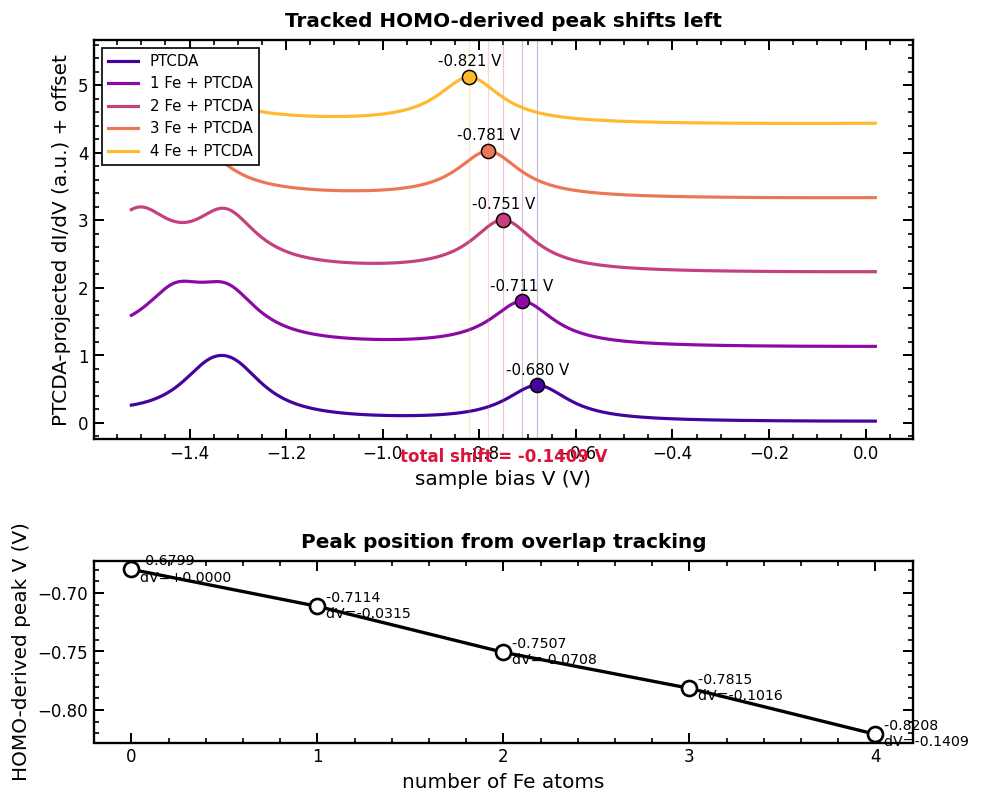

In [49]:
def ptcda_projection_weights(sol):
    return np.sum(np.abs(sol['orbitals'][:N_PTCDA_SITES, :])**2, axis=0)


def didv_spectrum(sol, V_axis, projection='ptcda'):
    centers = energy_to_bias(sol['energies'], params=sol['params'])
    if projection == 'ptcda':
        weights = ptcda_projection_weights(sol)
    elif projection == 'total':
        weights = None
    else:
        raise ValueError("projection must be 'ptcda' or 'total'")
    return broadened_spectrum(centers, V_axis, sol['params']['gamma'], weights=weights)


def plot_peak_shift_summary(label='HOMO', max_fe=4, params=None):
    rows = track_reference_orbital(label, max_fe=max_fe, params=params)
    V = np.linspace(min(r['bias'] for r in rows) - 0.7,
                    max(r['bias'] for r in rows) + 0.7, 2400)
    colors = plt.cm.plasma(np.linspace(0.10, 0.85, max_fe + 1))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.8, 7.6),
                                   gridspec_kw={'height_ratios': [2.2, 1.0],
                                                'hspace': 0.42})

    for n_fe, color in zip(range(max_fe + 1), colors):
        sol = solve_ptcda_fe(n_fe, params=params)
        y = normalize_peak(didv_spectrum(sol, V, projection='ptcda'))
        offset = 1.10 * n_fe
        row = rows[n_fe]
        py = np.interp(row['bias'], V, y) + offset
        ax1.plot(V, y + offset, color=color, lw=1.9,
                 label='PTCDA' if n_fe == 0 else f'{n_fe} Fe + PTCDA')
        ax1.scatter(row['bias'], py, s=72, color=color, edgecolor='black',
                    linewidth=0.9, zorder=4)
        ax1.text(row['bias'], py + 0.16, f"{row['bias']:+.3f} V",
                 ha='center', fontsize=9)
        ax1.axvline(row['bias'], color=color, lw=0.7, alpha=0.30)

    ax1.annotate('', xy=(rows[-1]['bias'], -0.30), xytext=(rows[0]['bias'], -0.30),
                 arrowprops={'arrowstyle': '->', 'lw': 1.8, 'color': 'crimson'})
    ax1.text(0.5*(rows[0]['bias'] + rows[-1]['bias']), -0.58,
             f'total shift = {rows[-1]["shift_V"]:+.4f} V',
             ha='center', color='crimson', fontweight='bold', fontsize=10)
    ax1.set_xlabel('sample bias V (V)')
    ax1.set_ylabel('PTCDA-projected dI/dV (a.u.) + offset')
    ax1.set_title(f'Tracked {label.upper()}-derived peak shifts left')
    ax1.legend(loc='upper left', fontsize=9)
    origin_style(ax1)

    x = [r['n_fe'] for r in rows]
    y = [r['bias'] for r in rows]
    ax2.plot(x, y, 'o-', color='black', lw=2.0, ms=9, mfc='white', mew=1.6)
    for r in rows:
        ax2.text(r['n_fe'], r['bias'],
                 f"  {r['bias']:+.4f}\n  dV={r['shift_V']:+.4f}",
                 ha='left', va='center', fontsize=8.5)
    ax2.set_xticks(x)
    ax2.set_xlabel('number of Fe atoms')
    ax2.set_ylabel(f'{label.upper()}-derived peak V (V)')
    ax2.set_title('Peak position from overlap tracking')
    origin_style(ax2)
    plt.show()
    return rows


peak_rows = plot_peak_shift_summary('HOMO')

## 7. Mechanism decomposition

Toggle Fe-O hopping and electrostatic stabilization independently. If perturbations are weak, the full shift should be close to the sum of both isolated shifts.

full model           final shift at 4 Fe: -0.1409 V
hybridization only   final shift at 4 Fe: -0.1234 V
electrostatic only   final shift at 4 Fe: -0.0191 V
nonlinear residual at 4 Fe: +0.0016 V


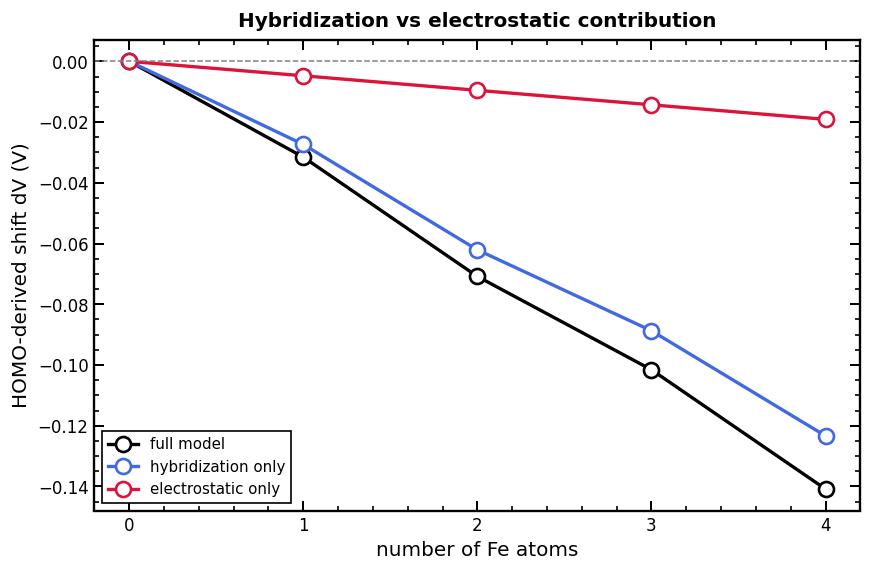

In [50]:
def plot_effect_decomposition(label='HOMO', params=None):
    configs = [
        ('full model',         True,  True,  'black'),
        ('hybridization only', True,  False, 'royalblue'),
        ('electrostatic only', False, True,  'crimson'),
    ]
    rows_by_config = {}
    fig, ax = plt.subplots(figsize=(7.4, 4.9))
    for name, hybrid, electro, color in configs:
        rows = track_reference_orbital(label, params=params,
                                       include_hybridization=hybrid,
                                       include_electrostatics=electro)
        rows_by_config[name] = rows
        ax.plot([r['n_fe'] for r in rows], [r['shift_V'] for r in rows],
                'o-', lw=2, ms=9, color=color, mfc='white', mew=1.6, label=name)
        print(f'{name:20s} final shift at 4 Fe: {rows[-1]["shift_V"]:+.4f} V')

    full = rows_by_config['full model'][-1]['shift_V']
    hyb = rows_by_config['hybridization only'][-1]['shift_V']
    elec = rows_by_config['electrostatic only'][-1]['shift_V']
    print(f'nonlinear residual at 4 Fe: {full - hyb - elec:+.4f} V')

    ax.axhline(0, color='0.5', lw=0.9, ls='--')
    ax.set_xticks(range(5))
    ax.set_xlabel('number of Fe atoms')
    ax.set_ylabel(f'{label.upper()}-derived shift dV (V)')
    ax.set_title('Hybridization vs electrostatic contribution')
    ax.legend(loc='best')
    origin_style(ax)
    plt.tight_layout()
    plt.show()
    return rows_by_config


effect_rows = plot_effect_decomposition('HOMO')

## 8. Quantum Dot orbital


```text
E_add(n_Fe, V_tip, z) = V_LUMO(n_Fe) + U_eff - alpha_tip(z) * V_tip
alpha_tip(z) = d_ms / (d_ms + z)
```



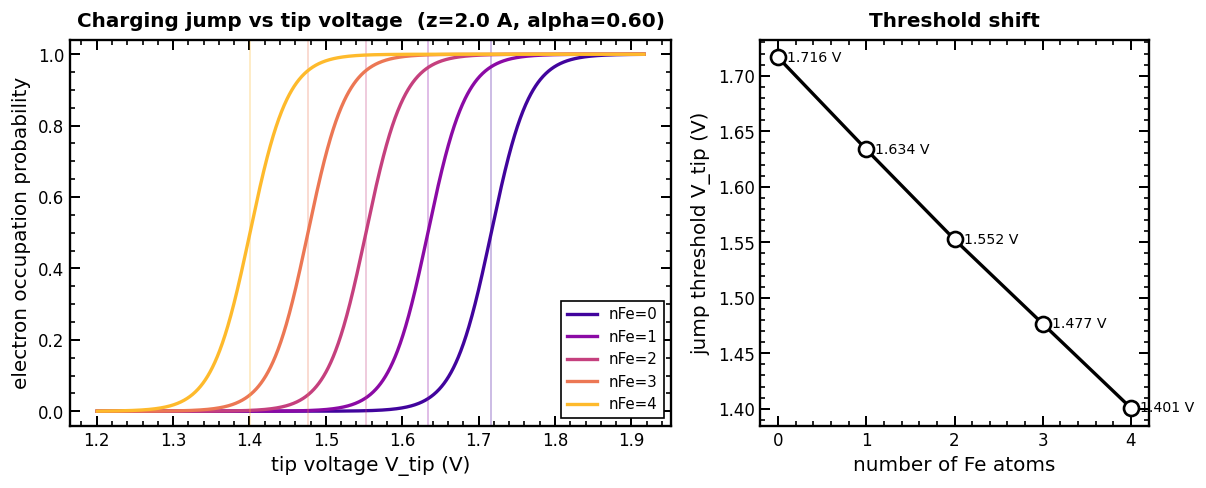

n_Fe  z(A)  alpha  LUMO_bias(V)  E_add(eV)  V_jump(V)  PTCDA overlap  Fe weight
   0   2.0  0.600       +0.6799    +1.0299    +1.7165       1.000       0.000
   1   2.0  0.600       +0.6301    +0.9801    +1.6336       0.959       0.033
   2   2.0  0.600       +0.5815    +0.9315    +1.5525       0.922       0.062
   3   2.0  0.600       +0.5359    +0.8859    +1.4766       0.900       0.086
   4   2.0  0.600       +0.4904    +0.8404    +1.4007       0.878       0.109


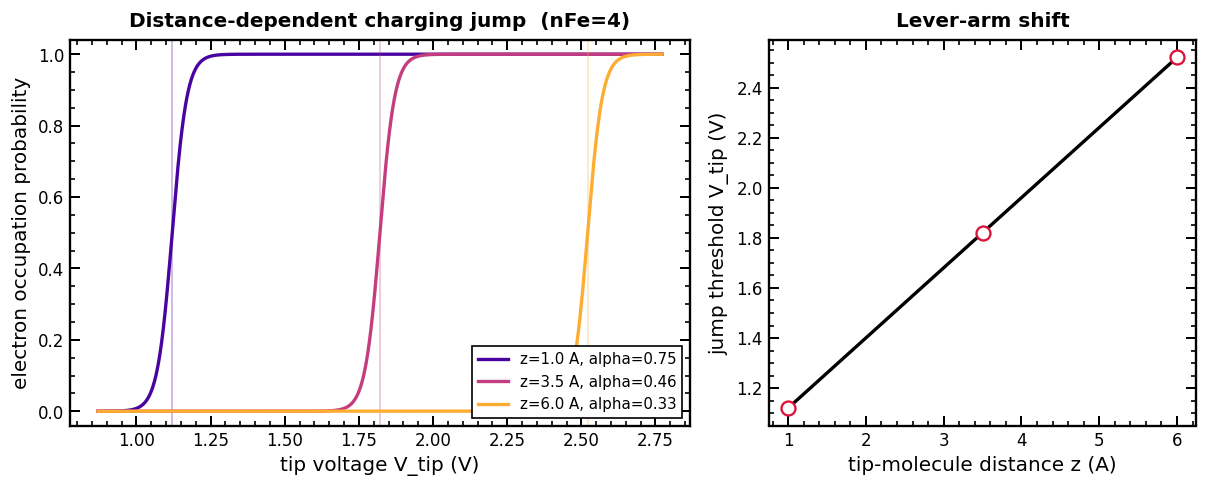

Distance sweep for n_Fe=4: LUMO=+0.4904 V, E_add=+0.8404 eV
z(A)  alpha  V_jump(V)
 1.0  0.750    +1.1205
 3.5  0.462    +1.8209
 6.0  0.333    +2.5212


In [51]:
def tip_lever_arm(z_tip, d_ms=3.0):
    """Minimal voltage-divider lever arm between tip and molecule."""
    z_tip = np.asarray(z_tip, dtype=float)
    return d_ms / (d_ms + z_tip)


def charging_thresholds(max_fe=4, params=None, U_eff=0.35,
                        z_tip=2.0, d_ms=3.0, alpha_tip=None):
    if alpha_tip is None:
        alpha_tip = float(tip_lever_arm(z_tip, d_ms=d_ms))
    lumo_rows = track_reference_orbital('LUMO', max_fe=max_fe, params=params)
    rows = []
    for r in lumo_rows:
        addition_energy = r['bias'] + U_eff
        rows.append({
            'n_fe': r['n_fe'],
            'lumo_bias': r['bias'],
            'addition_energy': addition_energy,
            'alpha_tip': alpha_tip,
            'z_tip': z_tip,
            'd_ms': d_ms,
            'v_jump': addition_energy / alpha_tip,
            'ptcda_overlap': r['ptcda_overlap'],
            'fe_weight': r['fe_weight'],
        })
    return rows


def jump_probability(V_tip, v_jump, width=0.025):
    return 1.0 / (1.0 + np.exp(-(np.asarray(V_tip) - v_jump) / width))


def plot_charging_jump(max_fe=4, params=None, U_eff=0.35,
                       z_tip=2.0, d_ms=3.0, width=0.025, alpha_tip=None):
    rows = charging_thresholds(max_fe=max_fe, params=params, U_eff=U_eff,
                               z_tip=z_tip, d_ms=d_ms, alpha_tip=alpha_tip)
    V_tip = np.linspace(min(r['v_jump'] for r in rows) - 0.20,
                        max(r['v_jump'] for r in rows) + 0.20, 1600)
    colors = plt.cm.plasma(np.linspace(0.10, 0.85, max_fe + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.2, 4.2),
                                   gridspec_kw={'width_ratios': [1.55, 1.0]})
    for r, color in zip(rows, colors):
        p = jump_probability(V_tip, r['v_jump'], width=width)
        ax1.plot(V_tip, p, color=color, lw=2.0, label=f"nFe={r['n_fe']}")
        ax1.axvline(r['v_jump'], color=color, lw=0.9, alpha=0.35)
    ax1.set_xlabel('tip voltage V_tip (V)')
    ax1.set_ylabel('electron occupation probability')
    ax1.set_title(f'Charging jump vs tip voltage  (z={rows[0]["z_tip"]:.1f} A, alpha={rows[0]["alpha_tip"]:.2f})')
    ax1.set_ylim(-0.04, 1.04)
    ax1.legend(loc='lower right')
    origin_style(ax1)

    x = [r['n_fe'] for r in rows]
    y = [r['v_jump'] for r in rows]
    ax2.plot(x, y, 'o-', color='black', lw=2.0, ms=9, mfc='white', mew=1.6)
    for r in rows:
        ax2.text(r['n_fe'], r['v_jump'], f"  {r['v_jump']:.3f} V", va='center', fontsize=8.5)
    ax2.set_xticks(x)
    ax2.set_xlabel('number of Fe atoms')
    ax2.set_ylabel('jump threshold V_tip (V)')
    ax2.set_title('Threshold shift')
    origin_style(ax2)
    plt.tight_layout()
    plt.show()

    print('n_Fe  z(A)  alpha  LUMO_bias(V)  E_add(eV)  V_jump(V)  PTCDA overlap  Fe weight')
    for r in rows:
        print(f"{r['n_fe']:>4d}  {r['z_tip']:>4.1f}  {r['alpha_tip']:>5.3f}"
              f"  {r['lumo_bias']:>+12.4f}  {r['addition_energy']:>+9.4f}"
              f"  {r['v_jump']:>+9.4f}     {r['ptcda_overlap']:>7.3f}     {r['fe_weight']:>7.3f}")
    return rows


def plot_charging_distance_dependence(n_fe=4, params=None, U_eff=0.35,
                                      z_range=(1.0, 6.0), n_z=80,
                                      d_ms=3.0, width=0.025):
    lumo_row = track_reference_orbital('LUMO', max_fe=n_fe, params=params)[n_fe]
    addition_energy = lumo_row['bias'] + U_eff
    z_values = np.linspace(z_range[0], z_range[1], n_z)
    alpha_values = tip_lever_arm(z_values, d_ms=d_ms)
    v_jump_values = addition_energy / alpha_values

    example_z = np.array([z_range[0], 0.5*(z_range[0] + z_range[1]), z_range[1]])
    example_alpha = tip_lever_arm(example_z, d_ms=d_ms)
    example_vjump = addition_energy / example_alpha
    V_tip = np.linspace(example_vjump.min() - 0.25, example_vjump.max() + 0.25, 1600)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.2, 4.2),
                                   gridspec_kw={'width_ratios': [1.45, 1.0]})
    colors = plt.cm.plasma(np.linspace(0.12, 0.82, len(example_z)))
    for z, alpha, vj, color in zip(example_z, example_alpha, example_vjump, colors):
        ax1.plot(V_tip, jump_probability(V_tip, vj, width=width),
                 color=color, lw=2.0, label=f'z={z:.1f} A, alpha={alpha:.2f}')
        ax1.axvline(vj, color=color, lw=0.9, alpha=0.35)
    ax1.set_xlabel('tip voltage V_tip (V)')
    ax1.set_ylabel('electron occupation probability')
    ax1.set_title(f'Distance-dependent charging jump  (nFe={n_fe})')
    ax1.set_ylim(-0.04, 1.04)
    ax1.legend(loc='lower right')
    origin_style(ax1)

    ax2.plot(z_values, v_jump_values, '-', color='black', lw=2.0)
    ax2.scatter(example_z, example_vjump, s=70, facecolor='white', edgecolor='crimson', linewidth=1.4, zorder=3)
    ax2.set_xlabel('tip-molecule distance z (A)')
    ax2.set_ylabel('jump threshold V_tip (V)')
    ax2.set_title('Lever-arm shift')
    origin_style(ax2)
    plt.tight_layout()
    plt.show()

    print(f'Distance sweep for n_Fe={n_fe}: LUMO={lumo_row["bias"]:+.4f} V, E_add={addition_energy:+.4f} eV')
    print('z(A)  alpha  V_jump(V)')
    for z, alpha, vj in zip(example_z, example_alpha, example_vjump):
        print(f'{z:>4.1f}  {alpha:>5.3f}  {vj:>+9.4f}')
    return {'z': z_values, 'alpha': alpha_values, 'v_jump': v_jump_values,
            'addition_energy': addition_energy, 'lumo_row': lumo_row}


charging_rows = plot_charging_jump(z_tip=2.0)
charging_distance = plot_charging_distance_dependence(n_fe=4)

## 9. Electron localization from orbital weights


$$ p_i = |c_i|^2, \qquad \sum_i p_i = 1, $$



- **center of probability** $\langle\mathbf r\rangle = \sum_i p_i \mathbf r_i$
- **rms spread** $\sigma_x,\,\sigma_y$ and total $\sigma = \sqrt{\sigma_x^2 + \sigma_y^2}$
- **inverse participation ratio** $\mathrm{IPR} = \sum_i p_i^2$ and $N_\text{eff} = 1/\mathrm{IPR}$
- **Fe weight** $\sum_{i\in\text{Fe}} p_i$

